In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [583]:
df_1 = pd.read_excel('correct_data_2015_all.xlsx')
df_2 = pd.read_excel('correct_data_2020_all.xlsx')

df = pd.concat([df_1, df_2], ignore_index=True)

df.dtypes

Уровень                                                                                                                         int64
Заказчик                                                                                                                       object
ИНН заказчика                                                                                                                   int64
Стоимость(руб.) Заказчик                                                                                                      float64
Реестровый номер публикации                                                                                                    object
Идентификационный код закупки                                                                                                  object
Сфера деятельности                                                                                                             object
Регион поставки                                               

In [3]:
df.head()

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,Статус допуска,"Снижение на торгах,%",Форма публикации,Тип торгов,Обеспечение заявки (руб.),"Обеспечение заявки, %",Обеспечение контракта (руб.),"Обеспечение контракта, %",РНП сейчас,РНП ранее
0,1,"АНО ""ДФИКММ ЧО""",7451432207,14641255.12,0321718002DP,NaN,"[ОКПД2 27.20] Батареи и аккумуляторы, [ОКВЭД2 ...",Челябинская область,Челябинск,2018-12-14 12:35:50,...,Допущен,0.048235,Торговая процедура,Иной способ,NaN,NaN,NaN,NaN,0,0
1,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,Не допущен,0.171902,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
2,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,Допущен,0.166269,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
3,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,Неизвестно,-0.089841,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
4,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,Неизвестно,-0.307809,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0


In [4]:
df.shape

(492078, 26)

In [3]:
df_3 = pd.read_excel('revenue_spark_final.xlsx')

In [49]:
df_3.head()

,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск
0,272909593,"450095, Башкортостан Респ, г.о. город Уфа, г У...","Торговля оптовая лесоматериалами, строительным...",NaN,1.0,Высокий риск
1,7805363761,"198095, г. Санкт-Петербург, ул. Зои Космодемья...",Строительство водных сооружений,5.959000e+07,14.0,Низкий риск
2,2320033513,"354000, Краснодарский кр., г. Сочи, проспект К...",Деятельность гостиниц и прочих мест для времен...,3.402400e+08,104.0,Низкий риск
3,7722327689,"630007, Новосибирская обл., г. Новосибирск, ул...",Деятельность курьерская,4.243533e+10,NaN,Низкий риск
4,6453128666,"410065, Саратовская обл., г. Саратов, ул. Одес...",Торговля оптовая одеждой и обувью,NaN,NaN,Недействующий


In [7]:
df_3.shape

(79912, 6)

In [38]:
print(df_3['Адрес'].isna().sum())
print(df_3['ИНН поставщика'].isna().sum())
print(df_3['Выручка'].isna().sum())
print(df_3['Персонал'].isna().sum())
print(df_3['Сводный риск'].isna().sum())
print(df_3['Отрасль'].isna().sum())

1100
0
23621
23050
121
1081


In [11]:
len(df_3['Адрес'].unique())

74185

In [12]:
len(df_3['ИНН поставщика'].unique())

79912

In [14]:
# количество дубликатов в строке "Адрес"
df_3['Адрес'].duplicated().sum()

5727

In [30]:
# количество адресов, по которым зарегистрировано более одной компании
repeated_addresses = df_3[df_3['Адрес'].duplicated(keep=False)].sort_values('Адрес')
repeated_addresses.shape

(7977, 6)

In [17]:
df_3[['Адрес', 'ИНН поставщика']].duplicated().sum()

0

Все поставщики уникальные, а адреса некоторые дублируются. Это означает, что есть разные компании (с разными ИНН), зарегистрированные по одному и тому же адресу

In [31]:
address_counts = df_3['Адрес'].value_counts()
print("Топ-10 адресов с наибольшим количеством компаний:")
print(address_counts.head(10))

Топ-10 адресов с наибольшим количеством компаний:
Адрес
Республика Саха(Якутия), Якутск                  110
Архангельская область, Архангельск                86
Чувашская Республика- Чувашия, Чебоксары          73
Краснодарский край, Краснодар, Прикубанский       71
Амурская область, Благовещенск                    48
Ставропольский край, Ставрополь, Промышленный     42
Краснодарский край, Краснодар, Карасунский        35
Республика Хакасия, Абакан                        35
Краснодарский край, Краснодар, Западный           34
Хабаровский край, Комсомольск-на-Амуре            32
Name: count, dtype: int64


In [33]:
df_3['Адрес'].unique()

array(['450095, Башкортостан Респ, г.о. город Уфа, г Уфа, ул Центральная, д. 23, офис 306',
       '198095, г. Санкт-Петербург, ул. Зои Космодемьянской, д. 20 литера А',
       '354000, Краснодарский кр., г. Сочи, проспект Курортный, д. 50',
       ..., '107589, г. Москва, ул. Красноярская, д. 11 к. А',
       '681024, Хабаровский край, г.о. город Комсомольск-на-Амуре, г Комсомольск-на-Амуре, пр-кт Интернациональный, д. 47, кв. 76',
       '454004, Челябинская обл., г. Челябинск, ул. Университетская Набережная, д. 94 кв. 58'],
      dtype=object)

Адресов очень много, и все записаны по-разному: есть просто с регионом и городом, а есть с очень подробным адресом, надо стандартизировать их запись

In [53]:
len(df_3['ИНН поставщика'].unique())

79912

In [304]:
    
region_types = {
        'белгородская': 'область',
        'брянская': 'область',
        'владимирская': 'область',
        'воронежская': 'область',
        'ивановская': 'область',
        'калужская': 'область',
        'костромская': 'область',
        'курская': 'область',
        'липецкая': 'область',
        'московская': 'область',
        'орловская': 'область',
        'рязанская': 'область',
        'смоленская': 'область',
        'тамбовская': 'область',
        'тверская': 'область',
        'тульская': 'область',
        'ярославская': 'область',
        'архангельская': 'область',
        'вологодская': 'область',
        'калининградская': 'область',
        'ленинградская': 'область',
        'мурманская': 'область',
        'новгородская': 'область',
        'псковская': 'область',
        'астраханская': 'область',
        'волгоградская': 'область',
        'ростовская': 'область',
        'кировская': 'область',
        'нижегородская': 'область',
        'оренбургская': 'область',
        'пензенская': 'область',
        'самарская': 'область',
        'саратовская': 'область',
        'ульяновская': 'область',
        'курганская': 'область',
        'свердловская': 'область',
        'тюменская': 'область',
        'челябинская': 'область',
        'кемеровская': 'область',
        'новосибирская': 'область',
        'томская': 'область',
        'омская': 'область',
        'иркутская': 'область',
        'амурская': 'область',
        'магаданская': 'область',
        'сахалинская': 'область',
        
        'алтайский': 'край',
        'краснодарский': 'край',
        'красноярский': 'край',
        'пермский': 'край',
        'приморский': 'край',
        'ставропольский': 'край',
        'хабаровский': 'край',
        'забайкальский': 'край',
        'камчатский': 'край',
        
        'адыгея': 'республика',
        'алтай': 'республика',
        'башкортостан': 'республика',
        'бурятия': 'республика',
        'дагестан': 'республика',
        'ингушетия': 'республика',
        'кабардино-балкарская': 'республика',
        'калмыкия': 'республика',
        'карачаево-черкесская': 'республика',
        'карелия': 'республика',
        'коми': 'республика',
        'марий эл': 'республика',
        'мордовия': 'республика',
        'саха': 'республика',
        'северная осетия': 'республика',
        'татарстан': 'республика',
        'тыва': 'республика',
        'удмуртская': 'республика',
        'хакасия': 'республика',
        'чеченская': 'республика',
        'чувашская': 'республика',
        'крым': 'республика',
        
        'ханты-мансийский': 'АО',
        'чукотский': 'АО',
        'ямало-ненецкий': 'АО',
        
        'москва': 'город',
        'санкт-петербург': 'город',
        'севастополь': 'город'
    }


major_cities = r'(?:Краснодар|Новосибирск|Владимир|Улан-Удэ|Астрахань|Дмитров|Ставрополь|Красноярск|Белореченск|Элиста|\
                    |Белгород|Ижевск|Сочи|Пермь|Уфа|Брянск|Мелеуз|Абакан|Якутск|Печора|Уссурийск|Набережные Челны|Барнаул|\
                    |Элиста|Губкин|Кемерово|Казань|Чебоксары|Мытищи|Бирск|Новороссийск|Владивосток|Можга|Урай|Волгоград|\
                    |Люберцы|Новороссийск|Котлас|Благовещенск|Горно-Алтайск|Салехард)'

In [338]:
city_pattern = '|'.join([
        r'(?:^|,\s*)(?:г\.?|город)\s+[^,]+',
        r'(?:^|,\s*)г\.о\.\s+(?:город\s+)?[^,]+',
        r'(?:^|,\s*)городской округ\s+(?:город\s+)?[^,]+',
        r'(?:^|,\s*)м\.о\.\s+[^,]+',
        r'(?:^|,\s*)(?:с\.|с)\s+[^,]+',
        r'(?:^|,\s*)(?:п\.|п|пос\.|пос)\s+([^,]+)',
        r'(?:^|,\s*)(?:пгт\.?|пгт)\s+[^,]+',
        major_cities
    ])

In [339]:
def analyze_address_components(address):
    if pd.isna(address):
        return pd.Series({
            'has_region': False,
            'has_city': False
        })

    region_pattern = r'(?:' + '|'.join([
        r'Ямало-Ненецкий\s+(?:АО|автономный округ|а\.о\.?)',
        r'Ненецкий\s+(?:АО|автономный округ|а\.о\.?)',
        r'Ханты-Мансийский\s+Автономный\s+Округ\s*-\s*Югра',
        r'Чувашская\s+Республика\s*-\s*Чувашия',
        r'Кемеровская\s+область\s*-\s*Кузбасс',
        r'Еврейская\s+авт\.\s*обл\.?',
        r'Крым\s+[Рр]есп\.?',
        
        r'Респ\.?|Республика',
        r'область|обл\.?',
        r'край|кр\.',
        r'АО|автономный округ|а\.о\.',
        
        r'г\.?|город\s+(?:Москва|Санкт-Петербург)',
        r'Севастополь',
        r'Байконур'
    ]) + ')'
    
    has_region = bool(re.search(region_pattern, address, re.IGNORECASE))
    
    has_city = bool(re.search(city_pattern, address, re.IGNORECASE))
    
    if 'севастополь' in address.lower():
        has_region = True
        if re.search(r'севастополь,\s*[^,]+,\s*[^,]+', address, re.IGNORECASE):
            has_city = True
        else:
            has_city = True
    
    return pd.Series({
        'has_region': has_region,
        'has_city': has_city
    })

address_components = df_3['Адрес'].apply(analyze_address_components)

print("Статистика по компонентам адресов:")
print(address_components.sum())

Статистика по компонентам адресов:
has_region    78812
has_city      76987
dtype: int64


In [340]:
print("Процент адресов с каждым компонентом:")
print((address_components.sum() / len(df_3) * 100).round(2))

Процент адресов с каждым компонентом:
has_region    98.62
has_city      96.34
dtype: float64


In [239]:
print((df_3['Адрес'].isna().sum() / len(df_3) * 100).round(2))

1.38


In [341]:
print("Процент адресов с каждым компонентом с учетом пропусков:")
print(address_components.sum() / len(df_3) * 100 + df_3['Адрес'].isna().sum() / len(df_3) * 100)

Процент адресов с каждым компонентом с учетом пропусков:
has_region    100.000000
has_city       97.716238
dtype: float64


In [297]:
missing_region_mask = ~address_components['has_region'] & ~df_3['Адрес'].isna()
print("Количество адресов без определенного региона:", missing_region_mask.sum())

Количество адресов без определенного региона: 0


In [310]:
missing_city_mask = ~df_3['Адрес'].apply(lambda x: bool(re.search(city_pattern, str(x), re.IGNORECASE))) & ~df_3['Адрес'].isna()

print("Количество адресов без определенного города:", missing_city_mask.sum())
print("\nПримеры таких адресов:")
df_3[missing_city_mask]['Адрес'].head(50)

Количество адресов без определенного города: 2304

Примеры таких адресов:


66      238314, Калининградская обл., Гурьевский район...
73      650517, Кемеровская область - Кузбасс, Кемеров...
107     452017, Башкортостан Респ, м.р-н Белебеевский,...
227      г. Санкт-Петербург, ул. Промышленная, д. 6 ли...
228                   Архангельская область, Северодвинск
309     614530, Пермский кр., Пермский район, д. Больш...
317      г. Санкт-Петербург, ул. Кораблестроителей, д....
367      г. Москва, проезд Нагатинский 1-Й, д. 15 этаж...
387     446290, Самарская обл, м.р-н Большечерниговски...
423     346748, Ростовская обл., Азовский район, хутор...
454     624006, Свердловская обл., Сысертский район, п...
461     174150, Новгородская обл., Шимский район, д. С...
497     460507, Оренбургская обл., Оренбургский район,...
529     460555, Оренбургская обл., Оренбургский район,...
551     634508, Томская обл., Томский район, пос. Кайд...
574     188518, Ленинградская обл., Ломоносовский райо...
590     188661, Ленинградская обл., Всеволожский район...
601     Арханг

Видно, что для некоторых адресов нет города, после региона сразу идет район, поэтому полученные 97.7% has_city довольно хорошо (города без явной пометки, что это город, постаралась обработать как можно больше)

In [342]:
def standardize_address(address):
    if pd.isna(address):
        return pd.Series({
            'Субъект': "Не указан",
            'Город': "Не указан"
        })
    
    region = None
    city = None
    
    special_regions = [
        (r'Еврейская\s+авт\.\s*обл\.?', 'Еврейская АО'),
        (r'Ямало-Ненецкий\s+(?:АО|автономный округ|а\.о\.?)', 'Ямало-Ненецкий АО'),
        (r'Ненецкий\s+(?:АО|автономный округ|а\.о\.?)', 'Ненецкий АО'),
        (r'Ханты-Мансийский\s+Автономный\s+Округ\s*-\s*Югра', 'Ханты-Мансийский АО'),
        (r'Чувашская\s+Республика\s*-\s*Чувашия', 'Чувашская Республика'),
        (r'Кемеровская\s+область\s*-\s*Кузбасс', 'Кемеровская область'),
        (r'Крым\s+[Рр]есп\.?', 'Республика Крым'),
        (r'Байконур', 'Байконур город')
    ]
    
    for pattern, replacement in special_regions:
        if re.search(pattern, address, re.IGNORECASE):
            region = replacement
            break
    
    if not region:
        for reg_name, reg_type in region_types.items():
            pattern = f"(?:{reg_name}\\s*(?:{reg_type}|обл\\.?|кр\\.?|респ\\.?|республика|ао|а\\.о\\.?)|{reg_name})"
            if re.search(pattern, address, re.IGNORECASE):
                region = f"{reg_name.capitalize()} {reg_type}"
                break
    
    city_indicators = [
        r'(?:^|,\s*)(?:г\.?|город)\s+([^,]+)',
        r'(?:^|,\s*)г\.о\.\s+(?:город\s+)?([^,]+)',
        r'(?:^|,\s*)городской округ\s+(?:город\s+)?([^,]+)',
        r'(?:^|,\s*)м\.о\.\s+([^,]+)',
        r'(?:^|,\s*)(?:с\.|с)\s+([^,]+)',
        r'(?:^|,\s*)(?:п\.|п|пос\.|пос)\s+([^,]+)',
        r'(?:^|,\s*)(?:пгт\.?|пгт)\s+([^,]+)'
    ]
    
    for pattern in city_indicators:
        match = re.search(pattern, address, re.IGNORECASE)
        if match:
            city = match.group(1).strip()
            city = re.sub(r'^(?:город\s+|г\.о\.\s+|городской округ\s+|м\.о\.\s+)', '', city, flags=re.IGNORECASE)
            break
    
    if not city:
        for major_city in major_cities.split('|'):
            major_city = major_city.strip()
            if re.search(r'\b' + re.escape(major_city) + r'\b', address, re.IGNORECASE):
                city = major_city
                break
    
    if 'севастополь' in address.lower():
        region = "Севастополь город"
        district_match = re.search(r'севастополь,\s*([^,]+)(?:,\s*([^,]+))?', address, re.IGNORECASE)
        if district_match:
            if district_match.group(2):
                city = district_match.group(2).strip()
            else:
                city = "Севастополь"
    
    return pd.Series({
        'Субъект': region if region else "Не определен",
        'Город': city if city else "Не определен"
    })


print("Примеры стандартизации адресов:")
sample_addresses = df_3['Адрес'].sample(n=20)
for addr in sample_addresses:
    print(f"\nОригинал: {addr}")
    print(f"Стандартизировано: {standardize_address(addr)}")

Примеры стандартизации адресов:

Оригинал: 432048, Ульяновская обл, г.о. город Ульяновск, г Ульяновск, ул Свободы, д. 10, этаж 2, офис 4
Стандартизировано: Субъект    Ульяновская область
Город                Ульяновск
dtype: object

Оригинал: 630049, Новосибирская обл, г.о. город Новосибирск, г Новосибирск, пр-кт Красный, д. 220/6, помещ. 2
Стандартизировано: Субъект    Новосибирская область
Город                Новосибирск
dtype: object

Оригинал: 603028, Нижегородская обл., г. Нижний Новгород, шоссе Московское, д. 219А пом. П1
Стандартизировано: Субъект    Нижегородская область
Город            Нижний Новгород
dtype: object

Оригинал: 117218, г. Москва, ул. Кржижановского, д. 15 к. 5 этаж 2 П V К 203 офис 1
Стандартизировано: Субъект    Москва город
Город            Москва
dtype: object

Оригинал: 141400, Московская обл., г. Химки, ул. Рабочая, д. 2А к. 2 пом. 28
Стандартизировано: Субъект    Московская область
Город                   Химки
dtype: object

Оригинал: 361401, Кабардино-

In [344]:
test_addresses = [
    "628634, Ханты-Мансийский Автономный Округ - Югра, Нижневартовский район, пгт. Излучинск, пер. Молодежный, д. 4 офис 25",
    "629601, Ямало-Ненецкий а.о., г. Муравленко, ул. Школьная, д. 24 пом. 1",
    "629830, Ямало-Ненецкий АО, г.о. город Губкинский, г Губкинский, тер. Панель 5, стр. 0005/1, офис 1",
    "166000, Ненецкий а.о., г. Нарьян-Мар, ул. Октябрьская, д. ЗД. 36"
]

print("Проверка на проблемных адресах:")
for addr in test_addresses:
    print(f"\nОригинал: {addr}")
    print(f"Стандартизировано: {standardize_address(addr)}")

Проверка на проблемных адресах:

Оригинал: 628634, Ханты-Мансийский Автономный Округ - Югра, Нижневартовский район, пгт. Излучинск, пер. Молодежный, д. 4 офис 25
Стандартизировано: Субъект    Ханты-Мансийский АО
Город                Излучинск
dtype: object

Оригинал: 629601, Ямало-Ненецкий а.о., г. Муравленко, ул. Школьная, д. 24 пом. 1
Стандартизировано: Субъект    Ямало-Ненецкий АО
Город             Муравленко
dtype: object

Оригинал: 629830, Ямало-Ненецкий АО, г.о. город Губкинский, г Губкинский, тер. Панель 5, стр. 0005/1, офис 1
Стандартизировано: Субъект    Ямало-Ненецкий АО
Город             Губкинский
dtype: object

Оригинал: 166000, Ненецкий а.о., г. Нарьян-Мар, ул. Октябрьская, д. ЗД. 36
Стандартизировано: Субъект    Ненецкий АО
Город       Нарьян-Мар
dtype: object


In [345]:
df_3[['Субъект поставщика', 'Город поставщика']] = df_3['Адрес'].apply(standardize_address)

In [348]:
df_3

,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск,Субъект поставщика,Город поставщика
0,272909593,"450095, Башкортостан Респ, г.о. город Уфа, г У...","Торговля оптовая лесоматериалами, строительным...",NaN,1.0,Высокий риск,Башкортостан республика,Уфа
1,7805363761,"198095, г. Санкт-Петербург, ул. Зои Космодемья...",Строительство водных сооружений,5.959000e+07,14.0,Низкий риск,Санкт-петербург город,Санкт-Петербург
2,2320033513,"354000, Краснодарский кр., г. Сочи, проспект К...",Деятельность гостиниц и прочих мест для времен...,3.402400e+08,104.0,Низкий риск,Краснодарский край,Сочи
3,7722327689,"630007, Новосибирская обл., г. Новосибирск, ул...",Деятельность курьерская,4.243533e+10,NaN,Низкий риск,Новосибирская область,Новосибирск
4,6453128666,"410065, Саратовская обл., г. Саратов, ул. Одес...",Торговля оптовая одеждой и обувью,NaN,NaN,Недействующий,Саратовская область,Саратов
...,...,...,...,...,...,...,...,...
79907,2466192870,"660028, Красноярский край, г.о. город Краснояр...",Производство электромонтажных работ,5.805300e+07,2.0,Низкий риск,Красноярский край,Красноярск
79908,2337022573,"353387, Краснодарский кр., Крымский район, г. ...",Строительство жилых и нежилых зданий,1.563000e+06,1.0,Низкий риск,Краснодарский край,Крымск
79909,7706193727,"107589, г. Москва, ул. Красноярская, д. 11 к. А",Производство электромонтажных работ,2.263000e+07,17.0,Высокий риск,Москва город,Москва
79910,5408302159,"681024, Хабаровский край, г.о. город Комсомоль...",Научные исследования и разработки в области ес...,5.503000e+06,NaN,Высокий риск,Хабаровский край,Комсомольск-на-Амуре


In [352]:
print(f"Кол-во пропусков субъектов: {df_3['Субъект поставщика'].isna().sum()}")
print(f"Кол-во пропусков городов: {df_3['Город поставщика'].isna().sum()}")

Кол-во пропусков субъектов: 0
Кол-во пропусков городов: 0


Смогли

In [614]:
df_3_subset = df_3[['ИНН поставщика', 'Субъект поставщика', 'Город поставщика', 'Выручка', 'Персонал', 'Сводный риск']]
df = df.merge(df_3_subset, on='ИНН поставщика', how='left')
df.shape

(492078, 33)

In [357]:
df.head()

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,"Обеспечение заявки, %",Обеспечение контракта (руб.),"Обеспечение контракта, %",РНП сейчас,РНП ранее,Субъект поставщика,Город поставщика,Выручка,Персонал,Сводный риск
0,1,"АНО ""ДФИКММ ЧО""",7451432207,14641255.12,0321718002DP,NaN,"[ОКПД2 27.20] Батареи и аккумуляторы, [ОКВЭД2 ...",Челябинская область,Челябинск,2018-12-14 12:35:50,...,NaN,NaN,NaN,0,0,Челябинская область,Челябинск,3.639350e+08,22.0,Низкий риск
1,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,NaN,NaN,NaN,0,0,Челябинская область,Челябинск,1.269900e+07,2.0,Высокий риск
2,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,NaN,NaN,NaN,0,0,Москва город,Москва,4.652704e+09,360.0,Низкий риск
3,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,NaN,NaN,NaN,0,0,Коми республика,Усинск,9.009080e+08,219.0,Низкий риск
4,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,NaN,NaN,NaN,0,0,Адыгея республика,Яблоновский,1.520000e+06,2.0,Высокий риск


In [358]:
df.columns

Index(['Уровень', 'Заказчик', 'ИНН заказчика', 'Стоимость(руб.) Заказчик',
       'Реестровый номер публикации', 'Идентификационный код закупки',
       'Сфера деятельности', 'Регион поставки', 'Город поставки',
       'Дата публикации',
       'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
       'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
       'Дата окончания проведения торгов', 'Поставщик', 'ИНН поставщика',
       'Победитель', 'Статус допуска', 'Снижение на торгах,%',
       'Форма публикации', 'Тип торгов', 'Обеспечение заявки (руб.)',
       'Обеспечение заявки, %', 'Обеспечение контракта (руб.)',
       'Обеспечение контракта, %', 'РНП сейчас', 'РНП ранее',
       'Субъект поставщика', 'Город поставщика', 'Выручка', 'Персонал',
       'Сводный риск'],
      dtype='object')

Теперь рассмотрим обеспечение контракта и заявки

In [ ]:
print(len(df['Обеспечение контракта, %'].unique()))
print(len(df['Обеспечение заявки, %'].unique()))


799
2108


In [387]:
security_columns = [
        'Обеспечение заявки (руб.)',
        'Обеспечение заявки, %',
        'Обеспечение контракта (руб.)',
        'Обеспечение контракта, %',
        'Стоимость(руб.) Заказчик'
    ]

print("Количество пропущенных значений:\n")
print(df[security_columns].isnull().sum())

Количество пропущенных значений:

Обеспечение заявки (руб.)       473558
Обеспечение заявки, %           473621
Обеспечение контракта (руб.)    458737
Обеспечение контракта, %        458737
Стоимость(руб.) Заказчик         46532
dtype: int64


In [424]:
def format_number(x):
    if pd.isna(x):
        return "NA"
    if isinstance(x, (int, float)):
        return f"{x:,.2f}".replace(",", " ")
    return str(x)

desc = df[security_columns].describe()

for col in security_columns:
    if col.endswith('руб.)') or col.startswith('Стоимость'):
        desc[col] = desc[col].apply(format_number)
    elif col.endswith('%'):
        desc[col] = desc[col].apply(lambda x: f"{x:.2f}%")
    
print(desc)

      Обеспечение заявки (руб.) Обеспечение заявки, %  \
count                 18 520.00             18457.00%   
mean                 744 863.46                 0.02%   
std                9 415 013.64                 0.10%   
min                        0.00                 0.00%   
25%                    5 000.00                 0.01%   
50%                   18 690.00                 0.01%   
75%                   99 566.31                 0.01%   
max              726 586 733.49                 3.78%   

      Обеспечение контракта (руб.) Обеспечение контракта, %  \
count                    33 341.00                33341.00%   
mean                    243 270.79                    0.08%   
std                   2 836 926.10                    0.06%   
min                           0.00                    0.00%   
25%                       6 200.00                    0.05%   
50%                      22 194.00                    0.05%   
75%                      72 301.50           

In [372]:
bid_calc_possible = df['Стоимость(руб.) Заказчик'].notna() & (
        (df['Обеспечение заявки (руб.)'].isna() & df['Обеспечение заявки, %'].notna()) |
        (df['Обеспечение заявки (руб.)'].notna() & df['Обеспечение заявки, %'].isna())
    )
    
contract_calc_possible = df['Стоимость(руб.) Заказчик'].notna() & (
    (df['Обеспечение контракта (руб.)'].isna() & df['Обеспечение контракта, %'].notna()) |
    (df['Обеспечение контракта (руб.)'].notna() & df['Обеспечение контракта, %'].isna())
)
    
print(f"Можно рассчитать обеспечение заявки: {bid_calc_possible.sum()} записей")
print(f"Можно рассчитать обеспечение контракта: {contract_calc_possible.sum()} записей")
    

Можно рассчитать обеспечение заявки: 0 записей
Можно рассчитать обеспечение контракта: 0 записей


In [391]:
bid_analysis = pd.DataFrame({
    'Количество записей': [
        len(df[df['Обеспечение заявки (руб.)'].notna() & 
                    df['Обеспечение заявки, %'].notna() & 
                    df['Стоимость(руб.) Заказчик'].notna()]),
        len(df[df['Обеспечение заявки (руб.)'].notna() & 
                    df['Обеспечение заявки, %'].isna() & 
                    df['Стоимость(руб.) Заказчик'].notna()]),
        len(df[df['Обеспечение заявки (руб.)'].isna() & 
                    df['Обеспечение заявки, %'].notna() & 
                    df['Стоимость(руб.) Заказчик'].notna()]),
        len(df[df['Обеспечение заявки (руб.)'].isna() & 
                    df['Обеспечение заявки, %'].isna() & 
                    df['Стоимость(руб.) Заказчик'].notna()])
    ]
}, index=[
    'Есть и рубли, и проценты',
    'Только рубли',
    'Только проценты',
    'Нет ни рублей, ни процентов'
])

print("Обеспечение заявки:")
print(bid_analysis)

Обеспечение заявки:
                             Количество записей
Есть и рубли, и проценты                  18457
Только рубли                                  0
Только проценты                               0
Нет ни рублей, ни процентов              427089


In [392]:
contract_analysis = pd.DataFrame({
    'Количество записей': [
        len(df[df['Обеспечение контракта (руб.)'].notna() & 
                    df['Обеспечение контракта, %'].notna() & 
                    df['Стоимость(руб.) Заказчик'].notna()]),
        len(df[df['Обеспечение контракта (руб.)'].notna() & 
                    df['Обеспечение контракта, %'].isna() & 
                    df['Стоимость(руб.) Заказчик'].notna()]),
        len(df[df['Обеспечение контракта (руб.)'].isna() & 
                    df['Обеспечение контракта, %'].notna() & 
                    df['Стоимость(руб.) Заказчик'].notna()]),
        len(df[df['Обеспечение контракта (руб.)'].isna() & 
                    df['Обеспечение контракта, %'].isna() & 
                    df['Стоимость(руб.) Заказчик'].notna()])
    ]
}, index=[
    'Есть и рубли, и проценты',
    'Только рубли',
    'Только проценты',
    'Нет ни рублей, ни процентов'
])

print("Обеспечение контракта:")
print(contract_analysis)

Обеспечение контракта:
                             Количество записей
Есть и рубли, и проценты                  33341
Только рубли                                  0
Только проценты                               0
Нет ни рублей, ни процентов              412205


Видно, что значения идут парами - если есть и стоимость, и обеспечение (заявки или контракта), то обеспечение дано и в процентах, и в рублях

In [425]:
desc = df['Стоимость(руб.) Заказчик'].describe()

desc = desc.apply(format_number)
print(desc)

count            445 546.00
mean           9 282 587.48
std          364 003 725.11
min                    0.01
25%              272 115.42
50%              760 000.00
75%            2 457 877.00
max      214 829 922 014.64
Name: Стоимость(руб.) Заказчик, dtype: object


In [421]:
print("Медиана:", df['Стоимость(руб.) Заказчик'].median())
print("90% перцентиль:", df['Стоимость(руб.) Заказчик'].quantile(0.9))
print("99% перцентиль:", df['Стоимость(руб.) Заказчик'].quantile(0.99))

Медиана: 760000.0
90% перцентиль: 7462500.0
99% перцентиль: 85356969.01199862


Судя по данным есть длинный хвост в распределении показателя стоимости, то есть есть небольшое количество очень больших значений, которые сильно влияют на среднее значение, а это может потом подпортить результаты моделей, поэтому логарифмируем столбец, так влияние выбросов будет меньше

Чтобы выбрать imputer, будем для тестирования создавать искусственные пропуски в полных данных. При использовании искусственных пропусков мы знаем истинные значения, можем посчитать точные метрики (MAE, MSE), сравнить распределения до и после заполнения. Также реальные пропуски могут быть не случайными, при искусственном создании - можно гарантировать их случайность

In [499]:
columns = [
        'Обеспечение заявки (руб.)', 
        'Обеспечение заявки, %',
        'Обеспечение контракта (руб.)', 
        'Обеспечение контракта, %',
        'Стоимость(руб.) Заказчик',
        'Выручка'
    ]
columns_for_log = [
        'Обеспечение заявки (руб.)', 
        'Обеспечение контракта (руб.)', 
        'Стоимость(руб.) Заказчик',
        'Выручка'   
    ]

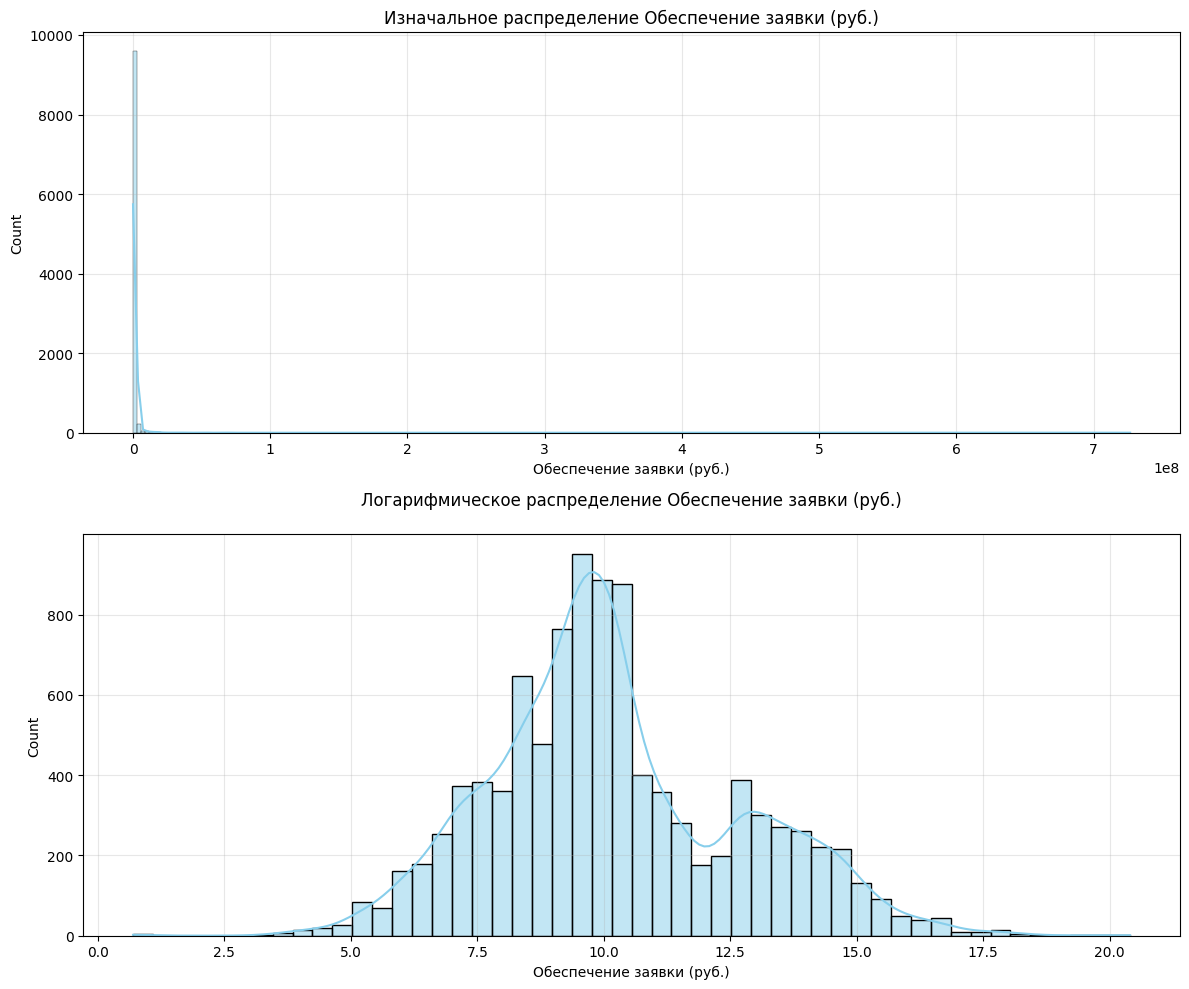


Statistics for Обеспечение заявки (руб.):
count         18 520.00
mean         744 863.46
std        9 415 013.64
min                0.00
25%            5 000.00
50%           18 690.00
75%           99 566.31
max      726 586 733.49
Name: Обеспечение заявки (руб.), dtype: object
--------------------------------------------------


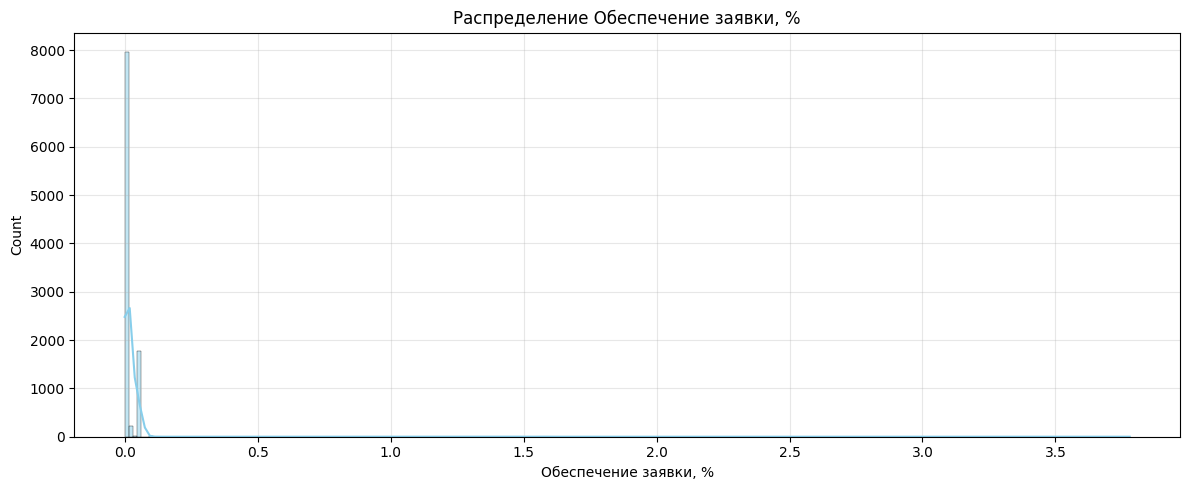


Statistics for Обеспечение заявки, %:
count    18 457.00
mean          0.02
std           0.10
min           0.00
25%           0.01
50%           0.01
75%           0.01
max           3.78
Name: Обеспечение заявки, %, dtype: object
--------------------------------------------------


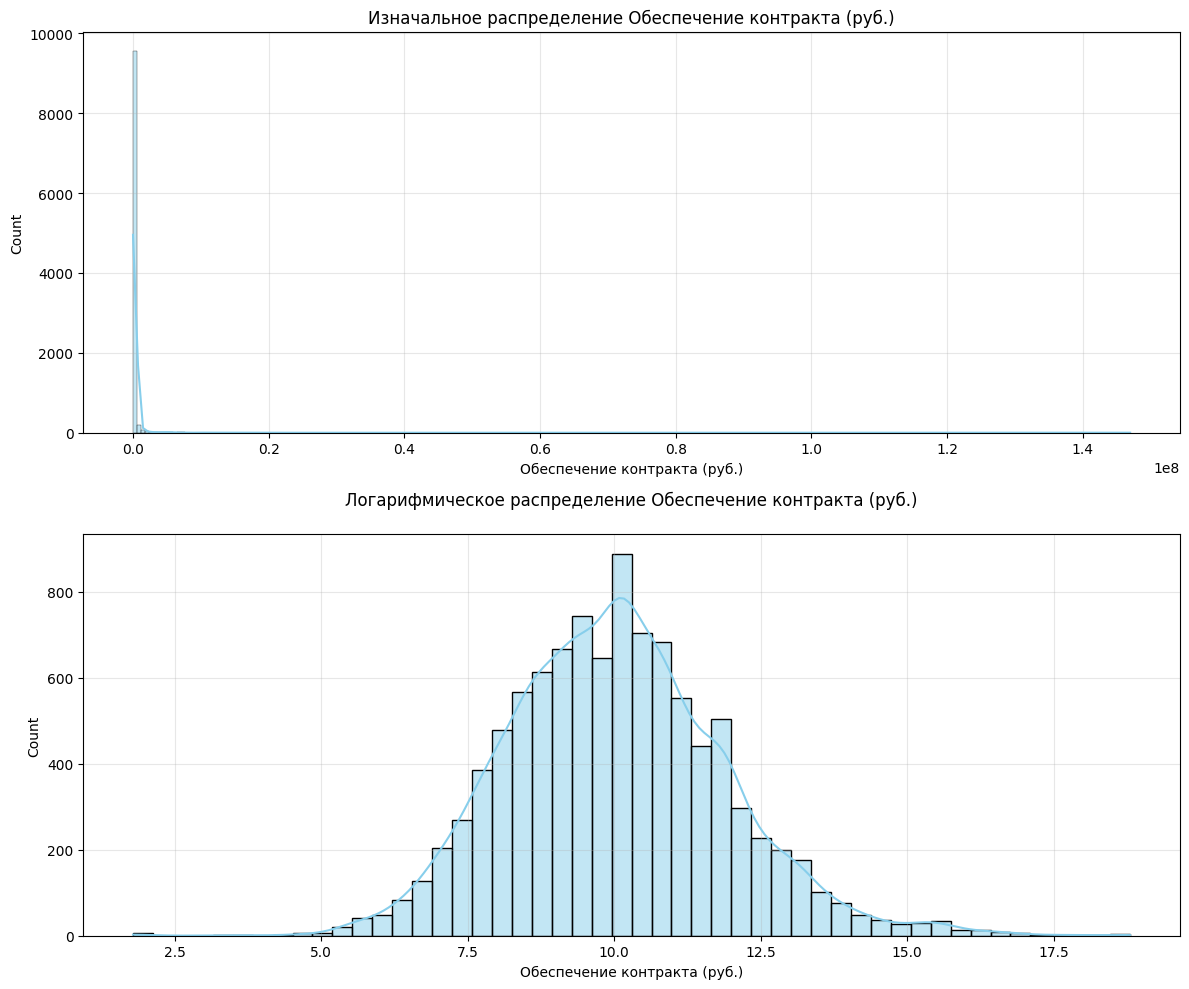


Statistics for Обеспечение контракта (руб.):
count         33 341.00
mean         243 270.79
std        2 836 926.10
min                0.00
25%            6 200.00
50%           22 194.00
75%           72 301.50
max      178 773 411.60
Name: Обеспечение контракта (руб.), dtype: object
--------------------------------------------------


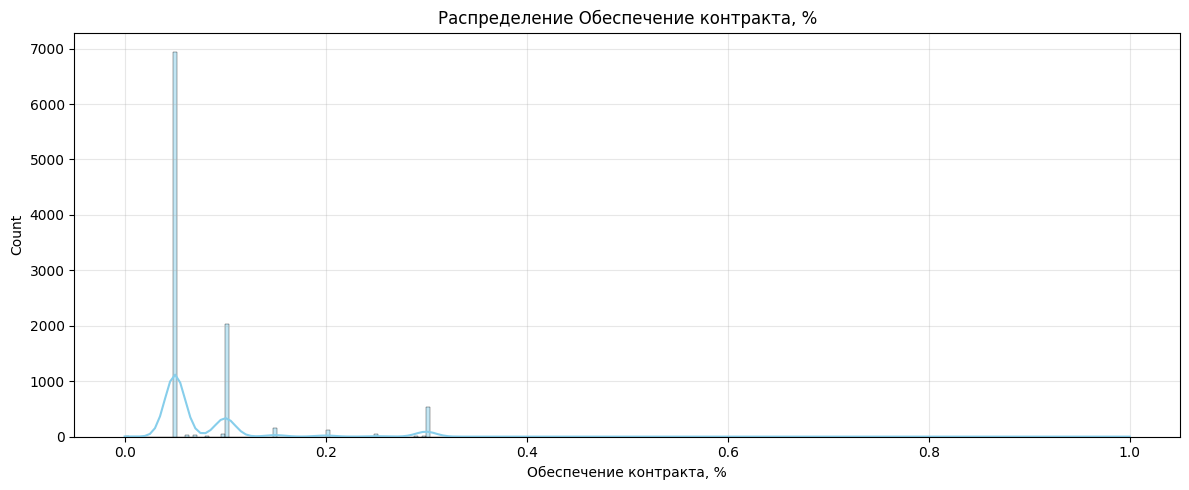


Statistics for Обеспечение контракта, %:
count    33 341.00
mean          0.08
std           0.06
min           0.00
25%           0.05
50%           0.05
75%           0.10
max           1.00
Name: Обеспечение контракта, %, dtype: object
--------------------------------------------------


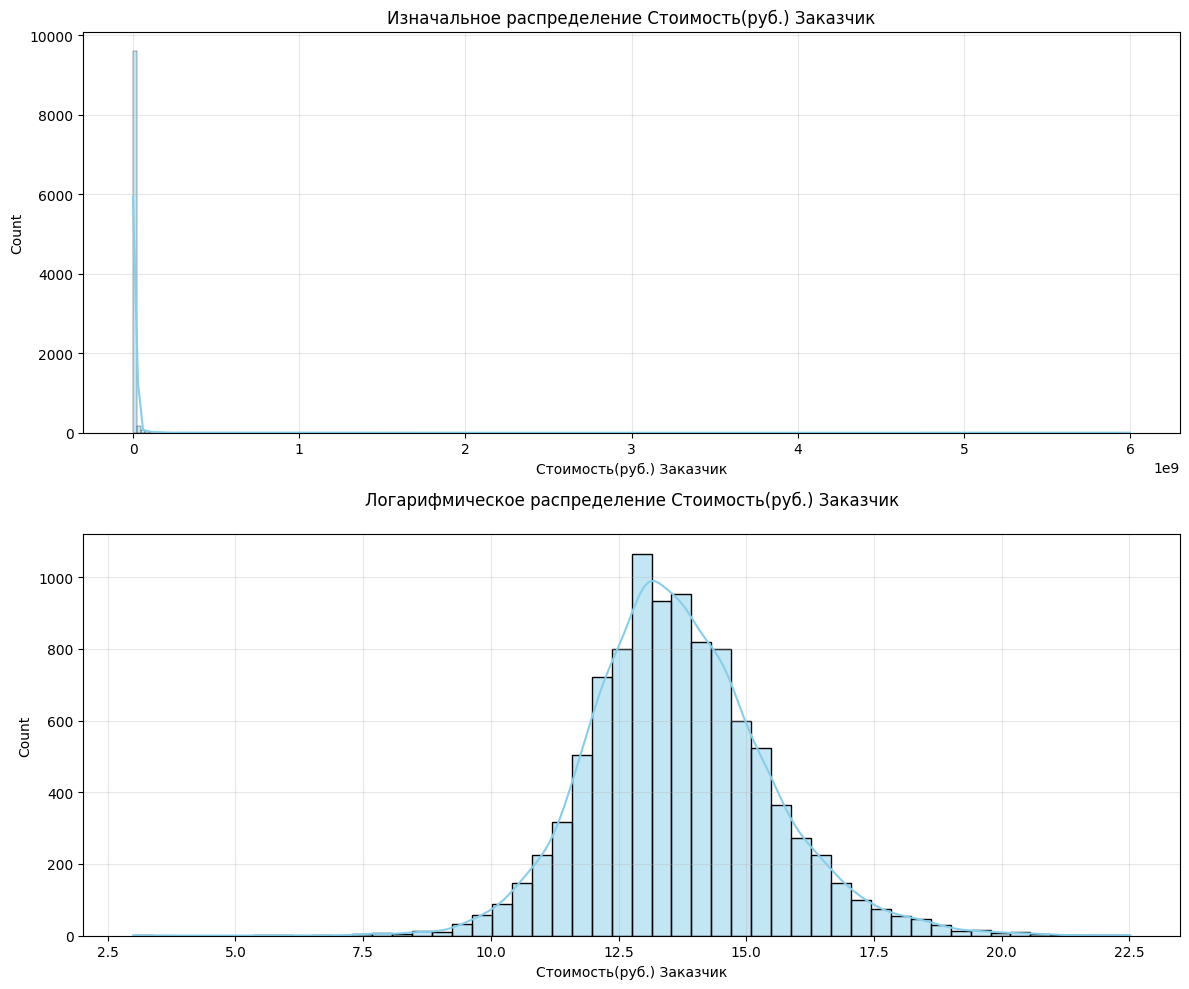


Statistics for Стоимость(руб.) Заказчик:
count            445 546.00
mean           9 282 587.48
std          364 003 725.11
min                    0.01
25%              272 115.42
50%              760 000.00
75%            2 457 877.00
max      214 829 922 014.64
Name: Стоимость(руб.) Заказчик, dtype: object
--------------------------------------------------


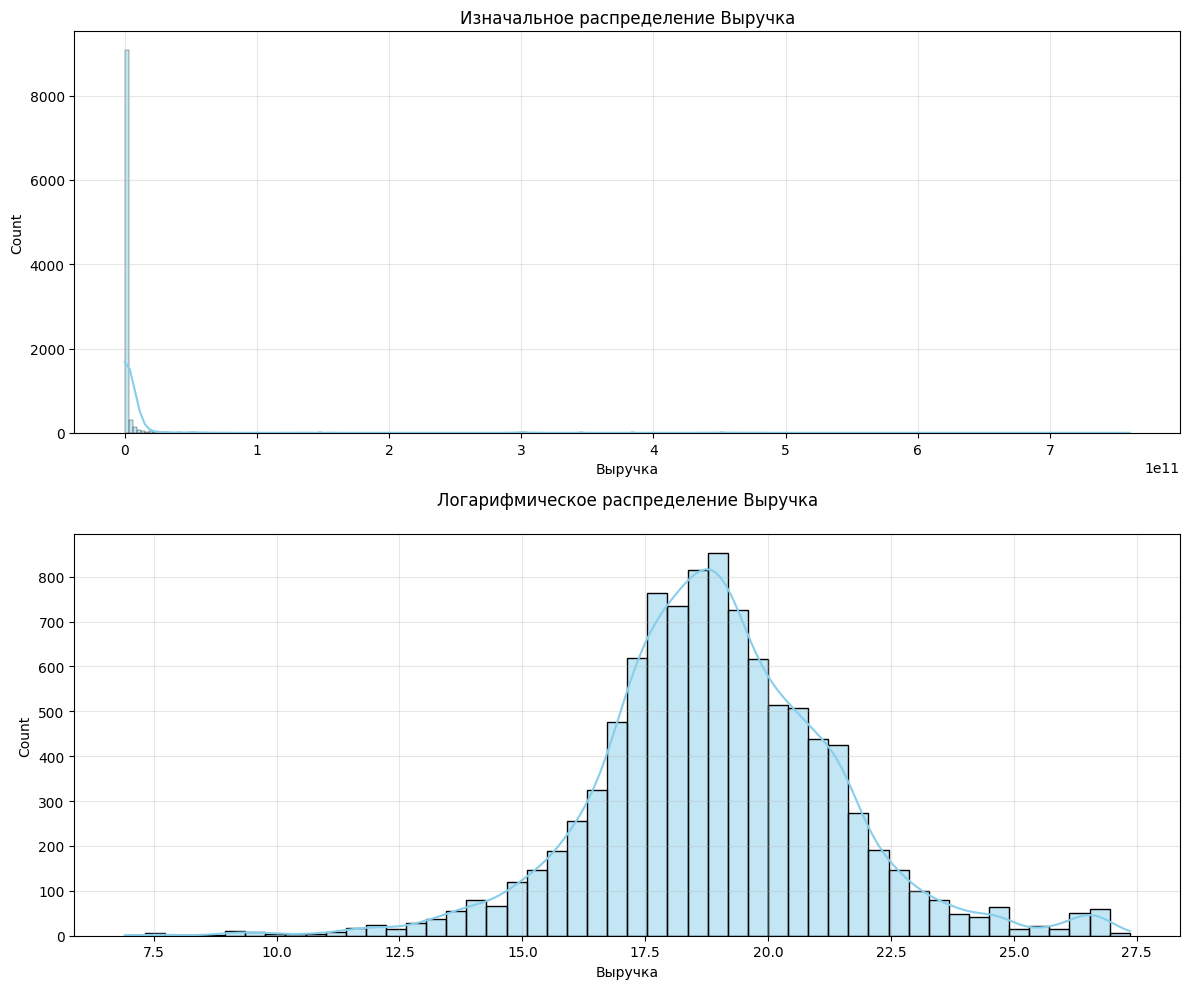


Statistics for Выручка:
count              313 091.00
mean         6 211 559 339.42
std         43 893 504 233.41
min             -1 800 000.00
25%             41 570 500.00
50%            155 690 000.00
75%            700 383 000.00
max      3 791 566 978 000.00
Name: Выручка, dtype: object
--------------------------------------------------


In [508]:
def plot_distributions(df, columns, columns_for_log):
    for col in columns:
        if col in columns_for_log:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
            
            data = df[col].dropna().sample(n=min(10000, len(df)))
            sns.histplot(data=data, 
                        kde=True, 
                        color='skyblue',
                        ax=ax1,
                        bins=250)
            ax1.set_title(f'Изначальное распределение {col}')
            ax1.grid(True, alpha=0.3)
            
            positive_data = data[data > 0]
            if len(positive_data) > 0:
                sns.histplot(data=np.log1p(positive_data), 
                            kde=True, 
                            color='skyblue',
                            ax=ax2,
                            bins=50)
                ax2.set_title(f'Логарифмическое распределение {col}\n')
                
            ax2.grid(True, alpha=0.3)
            
        else:
            plt.figure(figsize=(12, 5))
            sns.histplot(data=df[col].dropna().sample(n=min(10000, len(df))), 
                        kde=True, 
                        color='skyblue',
                        bins=250)
            
            plt.title(f'Распределение {col}')
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nStatistics for {col}:")
        print(df[col].dropna().describe().apply(format_number))
        print("-" * 50)

plot_distributions(df, columns, columns_for_log)

Как и предполагалось, рублевые признаки лучше логарифмировать, чтобы сделать распределение более близким к нормальному

In [591]:
def fill_median(data, target_column, group_columns=['Сфера деятельности', 'Регион поставки']):
    result = data[target_column].copy()
    temp_data = pd.concat([df[group_columns], result], axis=1)
        
    # медиана по всем столбцам из group_columns
    group_medians = temp_data.groupby(group_columns)[target_column].transform('median')
    result = result.fillna(group_medians)
        
    # медиана по каждой группе отдельно
    for group in group_columns:
        mask = result.isna()
        if mask.any():
            group_medians = temp_data.groupby(group)[target_column].transform('median')
            result = result.fillna(group_medians)
    
    # медиана по всем столбцам
    overall_median = result.median()
    if pd.isna(overall_median):
        overall_median = 0
    
    result = result.fillna(overall_median)
    
    return result

Если просто использовать KNN и Iterative только на одномерных данных (один столбец), то они показывают одинаковые результаты, чтобы это предотвратить, будет использоваться еще кросс-валидация, так проверка заполнения будет эффективнее

In [529]:
def format_number(x):
    if pd.isna(x):
        return "NA"
    if isinstance(x, (int, float)):
        return f"{x:,.5f}".replace(",", " ")
    return str(x)

In [533]:
def compare_imputation_methods(columns, columns_for_log):
    complete_data = df[columns].dropna()

    imputers = {
        'KNN': KNNImputer(n_neighbors=10, weights='distance'),
        'GroupMedian': lambda x: fill_median(x, x.columns[0]).values.reshape(-1, 1),
        'Iterative': IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=100, 
                max_depth=10
            ),
            max_iter=50,
            random_state=1,
            initial_strategy='median'
        )
    }
    
    n_splits = 5
    missing_percentages = [0.15, 0.3]
    
    for missing_pct in missing_percentages:
        print(f"\n{'='*50}")
        print(f"Тестирование с {missing_pct*100}% пропусков")
        print(f"{'='*50}")
        
        for column in columns:
            print(f"\n{'-'*20} {column} {'-'*20}")
            
            column_data = complete_data[[column]].copy()
            original_values = column_data[column].values
            
            if column in columns_for_log:
                column_data['log_values'] = np.log1p(column_data[column])
                working_column = 'log_values'
            else:
                working_column = column
            
            np.random.seed(42)
            eval_mask = np.random.rand(len(column_data)) < missing_pct
            df_eval_full = column_data[[working_column]].copy()
            df_eval_full.loc[eval_mask, working_column] = np.nan
            
            distribution_comparison = {}
            orig_stats = pd.Series(original_values).describe()
            distribution_comparison['Оригинал'] = orig_stats.apply(format_number)
            
            for name, imputer in imputers.items():
                if name == 'GroupMedian':
                    filled_values = imputer(df_eval_full)
                else:
                    filled_values = imputer.fit_transform(df_eval_full)
                
                if column in columns_for_log:
                    filled_original = np.expm1(filled_values)
                    filled_stats = pd.Series(filled_original.flatten()).describe()
                else:
                    filled_stats = pd.Series(filled_values.flatten()).describe()
                
                distribution_comparison[f'Заполнено_{name}'] = filled_stats.apply(format_number)
            
            print("\nСравнение распределений (в исходных единицах):")
            dist_df = pd.DataFrame(distribution_comparison)
            print(dist_df)
            
            kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            metrics_cv = {name: {'MSE': [], 'MAE': [], 'MAPE': []} for name in imputers.keys()}
            
            for train_idx, test_idx in kf.split(column_data):
                df_eval = column_data[[working_column]].copy()
                np.random.seed(42)
                eval_mask = np.random.rand(len(test_idx)) < missing_pct
                test_mask = np.zeros(len(column_data), dtype=bool)
                test_mask[test_idx[eval_mask]] = True
                df_eval.loc[test_mask, working_column] = np.nan
                
                for name, imputer in imputers.items():
                    if name == 'GroupMedian':
                        filled_values = imputer(df_eval)
                    else:
                        filled_values = imputer.fit_transform(df_eval)
                    
                    if column in columns_for_log:
                        filled_original = np.expm1(filled_values)
                        true_values = original_values[test_mask]
                        pred_values = filled_original[test_mask]
                    else:
                        true_values = original_values[test_mask]
                        pred_values = filled_values[test_mask]

                    metrics_cv[name]['MSE'].append(mean_squared_error(true_values, pred_values))
                    metrics_cv[name]['MAE'].append(mean_absolute_error(true_values, pred_values))
                    
                    if column in columns_for_log:
                        non_zero_mask = true_values != 0
                        if non_zero_mask.any():
                            mape = np.mean(np.abs((true_values[non_zero_mask] - pred_values[non_zero_mask]) / 
                                                true_values[non_zero_mask])) * 100
                            metrics_cv[name]['MAPE'].append(mape)
            
            metrics_formatted = {}
            for name in imputers.keys():
                metrics = {
                    'MSE': np.mean(metrics_cv[name]['MSE']),
                    'MAE': np.mean(metrics_cv[name]['MAE'])
                }
                if column in columns_for_log:
                    metrics['MAPE'] = np.mean(metrics_cv[name]['MAPE'])
                
                metrics_formatted[name] = {}
                for k, v in metrics.items():
                    if k == 'MAPE':
                        metrics_formatted[name][k] = f"{v:.2f}%"
                    else:
                        metrics_formatted[name][k] = format_number(v)
            
            metrics_df = pd.DataFrame(metrics_formatted).T
            print("\n", metrics_df)

    return metrics_cv

results = compare_imputation_methods(columns, columns_for_log)


Тестирование с 15.0% пропусков

-------------------- Обеспечение заявки (руб.) --------------------

Сравнение распределений (в исходных единицах):
               Оригинал     Заполнено_KNN Заполнено_GroupMedian  \
count       8 282.00000       8 282.00000           8 282.00000   
mean       94 097.55920      81 794.21796          85 983.21538   
std       961 352.43281     910 545.73304         915 598.43007   
min             1.00000           1.00000               1.00000   
25%         3 066.00000       4 396.08250           3 140.04000   
50%        12 237.62000       9 970.30827          12 260.87000   
75%        28 968.39750      24 509.88000          28 380.00000   
max    29 795 568.60000  29 795 568.60000      29 795 568.60000   

      Заполнено_Iterative  
count         8 282.00000  
mean         82 149.05866  
std         910 518.11660  
min               1.00000  
25%           4 396.08250  
50%          12 260.87000  
75%          24 509.88000  
max      29 795 568.600

Для денежных признаков (Обеспечение заявки (руб.), Обеспечение контракта (руб.), Стоимость(руб.) Заказчик, Выручка) MAPE важнее, потому что показывает относительную ошибку в процентах и позволяет сравнивать точность между разными масштабами денежных значений. Более понятная интерпретация, чем у того же MSE

Для процентных признаков (Обеспечение заявки, %, Обеспечение контракта, %) MAE важнее всего, потому что данные уже в процентах и она показывает абсолютную ошибку в тех же единицах, поэтому легко интерпретировать 

Теперь рассмотрим получившиеся значения:

1. Обеспечение заявки (руб.) - KNN
2. Обеспечение заявки, % - Iterative
3. Обеспечение контракта (руб.) - KNN
4. Обеспечение контракта, % - GroupMedian
5. Стоимость(руб.) Заказчик - KNN
6. Выручка - Iterative

In [534]:
knn_imputer = KNNImputer(n_neighbors=10, weights='distance')

iterative_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, max_depth=10),
    max_iter=50,
    random_state=1,
    initial_strategy='median'
)

In [535]:
df_filled = df.copy()

knn_columns = [
        'Обеспечение заявки (руб.)',
        'Обеспечение контракта (руб.)',
        'Стоимость(руб.) Заказчик'
    ]
    
for col in knn_columns:
    if col in df_filled.columns:
        temp_col = f"{col}_log"
        df_filled[temp_col] = np.log1p(df_filled[col])

log_cols = [f"{col}_log" for col in knn_columns if col in df_filled.columns]
if log_cols:
    filled_values = knn_imputer.fit_transform(df_filled[log_cols])
    for i, col in enumerate(knn_columns):
        if col in df_filled.columns:
            df_filled[col] = np.expm1(filled_values[:, i])
            df_filled.drop(f"{col}_log", axis=1, inplace=True)

df_filled['Выручка_log'] = np.log1p(df_filled['Выручка'])
df_filled['Выручка_log'] = iterative_imputer.fit_transform(df_filled[['Выручка_log']])[:, 0]
df_filled['Выручка'] = np.expm1(df_filled['Выручка_log'])
df_filled.drop('Выручка_log', axis=1, inplace=True)

df_filled['Обеспечение заявки, %'] = iterative_imputer.fit_transform(df_filled[['Обеспечение заявки, %']])[:, 0]
    
df_filled['Обеспечение контракта, %'] = fill_median(df_filled, 'Обеспечение контракта, %')

/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [541]:
print(df_filled[columns].isnull().sum())

stats = df_filled[columns].describe()
formatted_stats = stats.apply(lambda x: x.apply(format_number) if x.name != 'count' else x)
print("\n",formatted_stats)

Обеспечение заявки (руб.)       0
Обеспечение заявки, %           0
Обеспечение контракта (руб.)    0
Обеспечение контракта, %        0
Стоимость(руб.) Заказчик        0
Выручка                         0
dtype: int64

       Обеспечение заявки (руб.) Обеспечение заявки, %  \
count             492 078.00000         492 078.00000   
mean              134 622.82593               0.01042   
std             2 058 962.63525               0.01930   
min                     0.00000               0.00000   
25%                 2 971.46204               0.01000   
50%                 9 246.29026               0.01000   
75%                26 070.67172               0.01000   
max           726 586 733.49000               3.77936   

      Обеспечение контракта (руб.) Обеспечение контракта, %  \
count                492 078.00000            492 078.00000   
mean                 725 986.63892                  0.05926   
std                5 824 771.98189                  0.02451   
min            

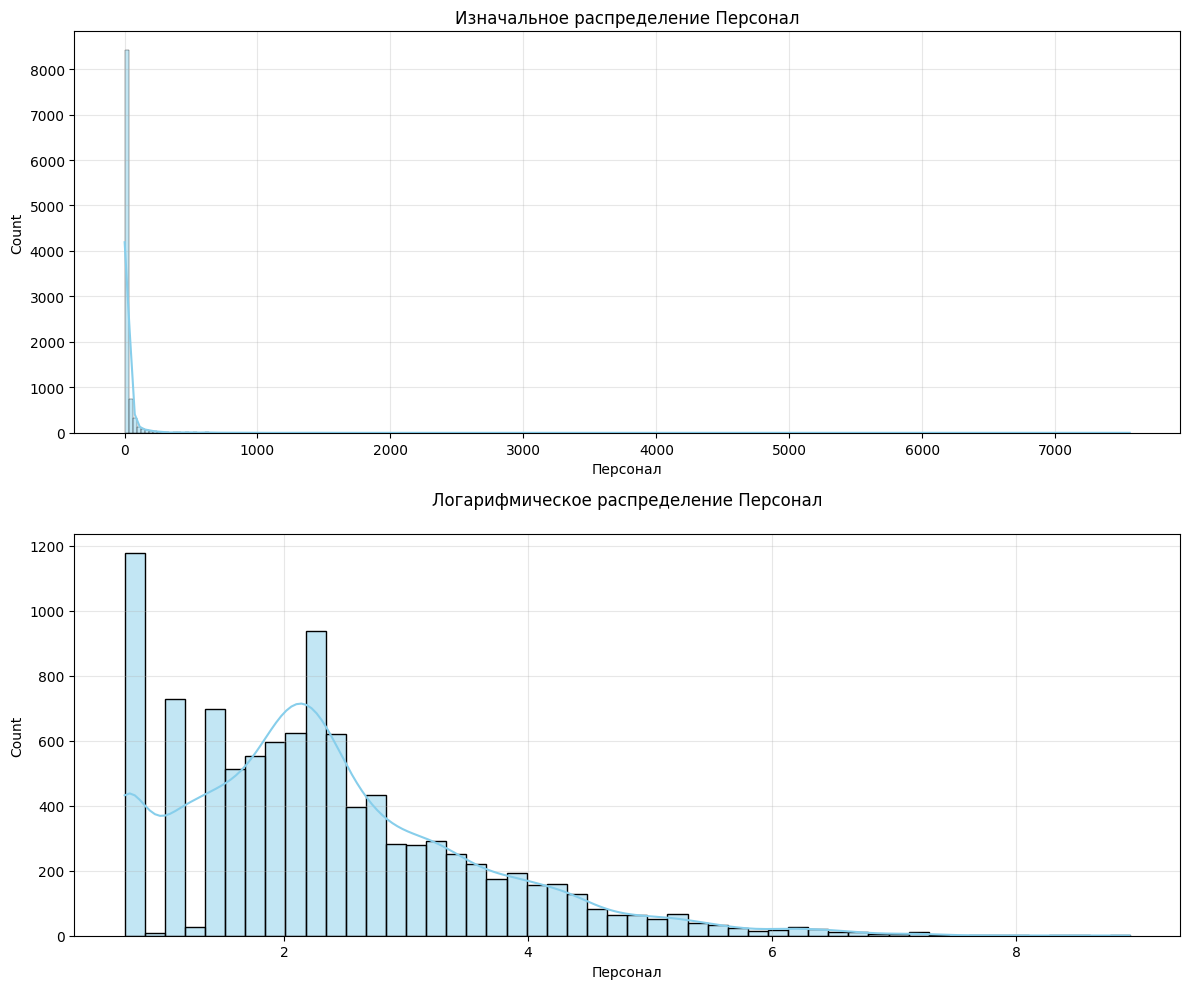


Statistics for Персонал:
count    79 912.00000
mean         30.72696
std         137.85478
min           1.00000
25%           3.00000
50%           8.00000
75%          18.00000
max       9 428.00000
Name: Персонал, dtype: object
--------------------------------------------------


In [600]:
columns_for_log.append('Персонал')

plot_distributions(df_filled, ['Персонал'], columns_for_log)

К нормальному распределению не получается прийти, слишком большая концентрация в области маленьких значений (медиана 11)

In [601]:
def compare_imputation_methods_simple(column_name):
    complete_data = df_filled[[column_name]].dropna()
    
    imputers = {
        'KNN': KNNImputer(n_neighbors=5, weights='uniform'),
        'GroupMedian': lambda x: fill_median(x, x.columns[0]).values.reshape(-1, 1),
        'Iterative': IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=50, max_depth=5),
            max_iter=10,
            random_state=1
        )
    }
    
    for missing_pct in [0.15, 0.30]:
        print(f"\nТестирование с {missing_pct*100}% пропусков")
        print(f"{'='*50}")
        
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        metrics_cv = {name: {'MSE': [], 'MAE': []} for name in imputers.keys()}
        
        np.random.seed(42)
        mask_full = np.random.rand(len(complete_data)) < missing_pct
        data_with_missing_full = complete_data.copy()
        data_with_missing_full.loc[mask_full, column_name] = np.nan
        
        original_values = complete_data[column_name].values
        distribution_comparison = {}
        orig_stats = pd.Series(original_values).describe()
        distribution_comparison['Оригинал'] = orig_stats.apply(format_number)
        
        for name, imputer in imputers.items():
            if name == 'GroupMedian':
                filled_values = imputer(data_with_missing_full)
            else:
                filled_values = imputer.fit_transform(data_with_missing_full)
            
            filled_stats = pd.Series(filled_values.flatten()).describe()
            distribution_comparison[f'Заполнено_{name}'] = filled_stats.apply(format_number)
            
            for train_idx, test_idx in kf.split(complete_data):
                mask = np.zeros(len(complete_data), dtype=bool)
                test_mask = np.random.rand(len(test_idx)) < missing_pct
                mask[test_idx[test_mask]] = True
                
                data_with_missing = complete_data.copy()
                data_with_missing.loc[mask, column_name] = np.nan
                
                if name == 'GroupMedian':
                    filled = imputer(data_with_missing)
                else:
                    filled = imputer.fit_transform(data_with_missing)
                
                true_vals = original_values[mask]
                pred_vals = filled[mask]
                
                metrics_cv[name]['MSE'].append(mean_squared_error(true_vals, pred_vals))
                metrics_cv[name]['MAE'].append(mean_absolute_error(true_vals, pred_vals))
        
        metrics_formatted = {}
        for name in imputers.keys():
            metrics = {
                'MSE': np.mean(metrics_cv[name]['MSE']),
                'MAE': np.mean(metrics_cv[name]['MAE'])
            }
            
            metrics_formatted[name] = {
                k: format_number(v) for k, v in metrics.items()
            }
        
        print(pd.DataFrame(distribution_comparison))
        print(pd.DataFrame(metrics_formatted).T)

results = compare_imputation_methods_simple('Персонал')


Тестирование с 15.0% пропусков
           Оригинал Заполнено_KNN Заполнено_GroupMedian Заполнено_Iterative
count  79 912.00000  79 912.00000          79 912.00000        79 912.00000
mean       30.72696      30.29040              27.91252            30.29040
std       137.85478     122.99313             125.02107           122.99313
min         1.00000       1.00000               1.00000             1.00000
25%         3.00000       4.00000               4.00000             4.00000
50%         8.00000      10.00000               8.00000            10.00000
75%        18.00000      30.29040              17.00000            30.29040
max     9 428.00000   9 428.00000           9 428.00000         9 428.00000
                      MSE       MAE
KNN          16 714.03415  37.95243
GroupMedian  20 870.51641  26.67053
Iterative    11 855.62731  35.72563

Тестирование с 30.0% пропусков
           Оригинал Заполнено_KNN Заполнено_GroupMedian Заполнено_Iterative
count  79 912.00000  79 912.0000

Здесь смотрим по MАЕ - наиболее интерпретируема, показывает среднюю ошибку в тех же единицах, не так сильно штрафует за выбросы, хорошо подходит для целочисленных значений. Лучший вариант - заполнение медианами

In [602]:
df_filled['Персонал'] = fill_median(df_filled, 'Персонал')

print(df_filled['Персонал'].isnull().sum())
print("\n",df_filled['Персонал'].describe().apply(format_number))

0

 count    492 078.00000
mean          15.23818
std           68.01003
min            1.00000
25%            6.00000
50%            8.00000
75%           10.00000
max        9 428.00000
Name: Персонал, dtype: object


In [587]:
columns.append('Персонал')

In [610]:
df[columns] = df_filled[columns]

print(df[columns].isnull().sum())

Обеспечение заявки (руб.)       0
Обеспечение заявки, %           0
Обеспечение контракта (руб.)    0
Обеспечение контракта, %        0
Стоимость(руб.) Заказчик        0
Выручка                         0
Персонал                        0
dtype: int64


In [543]:
df['Реестровый номер публикации'].unique()

array(['0321718002DP', '0321718003DP', '1000111', ..., 32313076531,
       32110715993, 32110597338], dtype=object)

In [611]:
date_columns = df.select_dtypes('datetime64[ns]').columns
date_columns

Index(['Дата публикации',
       'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
       'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ'],
      dtype='object')

In [552]:
df.dtypes

Уровень                                                                                                                         int64
Заказчик                                                                                                                       object
ИНН заказчика                                                                                                                   int64
Стоимость(руб.) Заказчик                                                                                                      float64
Реестровый номер публикации                                                                                                    object
Идентификационный код закупки                                                                                                  object
Сфера деятельности                                                                                                             object
Регион поставки                                               

In [612]:
for col in df.columns:
    print(f"Столбец: {col}")
    print(f"Тип данных: {df[col].dtype}")
    print(f"Количество уникальных значений: {df[col].nunique()}")
    print(f"Количество пропущенных значений: {df[col].isna().sum()}")
    if df[col].nunique() <= 10:
        print(f"Уникальные значения: {df[col].unique()}")
    print("-" * 20)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop(['ИНН заказчика', 'ИНН поставщика', 'РНП сейчас', 'РНП ранее'])
for col in numerical_cols:
    print(f'Столбец: {col}')
    print(f'Минимум: {df[col].min()}')
    print(f'Максимум: {df[col].max()}')
    print(f'Среднее: {df[col].mean()}')
    print(f'Медиана: {df[col].median()}')
    print("-" * 20)

Столбец: Уровень
Тип данных: int64
Количество уникальных значений: 2
Количество пропущенных значений: 0
Уникальные значения: [1 2]
--------------------
Столбец: Заказчик
Тип данных: object
Количество уникальных значений: 16989
Количество пропущенных значений: 0
--------------------
Столбец: ИНН заказчика
Тип данных: int64
Количество уникальных значений: 17416
Количество пропущенных значений: 0
--------------------
Столбец: Стоимость(руб.) Заказчик
Тип данных: float64
Количество уникальных значений: 164149
Количество пропущенных значений: 0
--------------------
Столбец: Реестровый номер публикации
Тип данных: object
Количество уникальных значений: 224078
Количество пропущенных значений: 0
--------------------
Столбец: Идентификационный код закупки
Тип данных: object
Количество уникальных значений: 12973
Количество пропущенных значений: 458321
--------------------
Столбец: Сфера деятельности
Тип данных: object
Количество уникальных значений: 20505
Количество пропущенных значений: 14
----

In [554]:
df['Тип торгов'].unique()

array(['Иной способ', nan, 'Запрос предложений', 'Запрос котировок',
       'Прямые закупки', 'Запрос цен', 'Конкурс открытый',
       'Запрос котировок в электронной форме',
       'Запрос предложений в электронной форме',
       'Закупка у единственного поставщика (исполнителя, подрядчика)',
       'Аукцион электронный', 'Аукцион открытый',
       'Отбор квалификационный', 'Открытый конкурс в электронной форме',
       'Запрос котировок закрытый',
       'Запрос предложений с квалификационным отбором',
       'Переговоры конкурентные',
       'Переговоры конкурентные с квалификационным отбором',
       'Аукцион с квалификационным отбором',
       'Запрос котировок с квалификационным отбором', 'Мелкая закупка',
       'Конкурс открытый с ограниченным участием (с предквалификационным отбором)',
       'Маркетинговое исследование', 'Внутригрупповые закупки',
       'Отбор предварительный', 'Запрос предложений закрытый',
       'Аукцион закрытый', 'Конкурс двухэтапный'], dtype=object)

In [606]:
cross_table = pd.crosstab(df['Победитель'], df['Статус допуска'], margins=True)
print(cross_table)

print("\nРаспределение статуса допуска для победителей:")
print(df[df['Победитель'] == 'Победитель']['Статус допуска'].value_counts(normalize=True))

print("\nРаспределение статуса допуска для не победителей:")
print(df[df['Победитель'].isna()]['Статус допуска'].value_counts(normalize=True))

Статус допуска  Допущен  Не допущен  Неизвестно     All
Победитель                                             
Победитель       227967           7        8329  236303
All              227967           7        8329  236303

Распределение статуса допуска для победителей:
Статус допуска
Допущен       0.964723
Неизвестно    0.035247
Не допущен    0.000030
Name: proportion, dtype: float64

Распределение статуса допуска для не победителей:
Статус допуска
Допущен       0.851577
Не допущен    0.094255
Неизвестно    0.054169
Name: proportion, dtype: float64


Видим, что почти все победители имеют статус "Допущен" (96.4%). Среди не победителей доля "Допущенных" меньше (85.2%), а доли "Неизвестно" и "Не допущен" выше, значит, есть связь между статусом допуска и победой в тендере. Преобразуем "Статус допуска" в бинарный признак, а также заменим "Неизвестно" на "Допущен" только для победителей



In [607]:
df['Target'] = (df['Победитель'] == 'Победитель').astype(int)
df = df.drop('Победитель', axis=1)

df.loc[(df['Target'] == 1) & (df['Статус допуска'] == 'Неизвестно'), 'Статус допуска'] = 'Допущен'

df['Допущен'] = df['Статус допуска'].apply(lambda x: 1 if x == 'Допущен' else 0)
df = df.drop('Статус допуска', axis=1)

In [618]:
df.columns

Index(['Уровень', 'Заказчик', 'ИНН заказчика', 'Стоимость(руб.) Заказчик',
       'Реестровый номер публикации', 'Сфера деятельности', 'Регион поставки',
       'Город поставки', 'Дата публикации',
       'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
       'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
       'Дата окончания проведения торгов', 'Поставщик', 'ИНН поставщика',
       'Снижение на торгах,%', 'Форма публикации', 'Тип торгов',
       'Обеспечение заявки (руб.)', 'Обеспечение заявки, %',
       'Обеспечение контракта (руб.)', 'Обеспечение контракта, %',
       'РНП сейчас', 'РНП ранее', 'Выручка_x', 'Персонал_x', 'Target',
       'Допущен', 'Субъект поставщика', 'Город поставщика', 'Выручка_y',
       'Персонал_y', 'Сводный риск'],
      dtype='object')

In [608]:
for col in df.columns:
    print(f"Столбец: {col}")
    missing_ratio = df[col].isna().sum() / len(df)
    print(f"Доля пропусков: {missing_ratio:.2%}", "\n")

Столбец: Уровень
Доля пропусков: 0.00% 

Столбец: Заказчик
Доля пропусков: 0.00% 

Столбец: ИНН заказчика
Доля пропусков: 0.00% 

Столбец: Стоимость(руб.) Заказчик
Доля пропусков: 0.00% 

Столбец: Реестровый номер публикации
Доля пропусков: 0.00% 

Столбец: Идентификационный код закупки
Доля пропусков: 93.14% 

Столбец: Сфера деятельности
Доля пропусков: 0.00% 

Столбец: Регион поставки
Доля пропусков: 0.00% 

Столбец: Город поставки
Доля пропусков: 0.00% 

Столбец: Дата публикации
Доля пропусков: 0.00% 

Столбец: Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ
Доля пропусков: 0.00% 

Столбец: Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ
Доля пропусков: 0.00% 

Столбец: Дата окончания проведения торгов
Доля пропусков: 0.00% 

Столбец: Поставщик
Доля пропусков: 0.00% 

Столбец: ИНН поставщика
Доля пропусков: 0.00% 

Столбец: Снижение на торгах,%
Доля пропусков: 0.00% 

Столбец: Форм

In [566]:
df['Сводный риск'].unique()

array(['Низкий риск', 'Высокий риск', 'Средний риск', 'Недействующий',
       'Риск не определен', nan], dtype=object)

Идентификационный код закупки: доля пропусков - 93.14%, очень много, но есть реестровый номер публикации, поэтому можем не рассматривать дальше этот признак

Тип торгов: доля пропусков - 78.74%, довольно большая доля пропусков, заменим неизвестные значения на "Неизвестно", чтобы не искажать сильно распределение

Субъект, город поставщика и сводный риск: доля пропусков - 13.02-13.05%. В случае субъекта и города - заполним на "Неизвестно", для сводного риска заменим неизвестные значения на "Риск не определен"

In [615]:
df['Субъект поставщика'] = df['Субъект поставщика'].fillna('Неизвестно')
df['Город поставщика'] = df['Город поставщика'].fillna('Неизвестно')
df['Тип торгов'] = df['Тип торгов'].fillna('Неизвестно')
df['Сводный риск'] = df['Сводный риск'].fillna('Риск не определен')
df = df.drop(['Идентификационный код закупки'], axis=1)

In [621]:
for col in df.columns:
    print(f"Столбец: {col}")
    print(f"Тип данных: {df[col].dtype}")
    print(f"Количество уникальных значений: {df[col].nunique()}")
    print(f"Количество пропущенных значений: {df[col].isna().sum()}")
    if df[col].nunique() <= 10:
        print(f"Уникальные значения: {df[col].unique()}")
    print("-" * 20)

Столбец: Уровень
Тип данных: int64
Количество уникальных значений: 2
Количество пропущенных значений: 0
Уникальные значения: [1 2]
--------------------
Столбец: Заказчик
Тип данных: object
Количество уникальных значений: 16989
Количество пропущенных значений: 0
--------------------
Столбец: ИНН заказчика
Тип данных: int64
Количество уникальных значений: 17416
Количество пропущенных значений: 0
--------------------
Столбец: Стоимость(руб.) Заказчик
Тип данных: float64
Количество уникальных значений: 164149
Количество пропущенных значений: 0
--------------------
Столбец: Реестровый номер публикации
Тип данных: object
Количество уникальных значений: 224078
Количество пропущенных значений: 0
--------------------
Столбец: Сфера деятельности
Тип данных: object
Количество уникальных значений: 20505
Количество пропущенных значений: 14
--------------------
Столбец: Регион поставки
Тип данных: object
Количество уникальных значений: 133
Количество пропущенных значений: 0
--------------------
Стол

Для сферы деятельности всего 14 пропусков, удалим эти строки

In [627]:
df = df.dropna(subset=['Сфера деятельности'])

In [622]:
print("Уникальные значения в столбце 'Регион поставки':")
print(df['Регион поставки'].unique())

Уникальные значения в столбце 'Регион поставки':
['Челябинская область' 'Архангельская область' 'Республика Коми'
 'Республика Северная Осетия-Алания' 'Мурманская область'
 'Краснодарский край' 'Пермский край' 'Московская область'
 'Республика Башкортостан' 'Республика Марий Эл' 'Рязанская область'
 'Владимирская область' 'Калужская область' 'Тульская область' 'Москва'
 'Нижегородская область' 'Оренбургская область' 'Удмуртская Республика'
 'Республика Дагестан' 'Хабаровский край'
 'Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан'
 'Чеченская Республика'
 'Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан'
 'Республика Татарстан (Татарстан)' 'Красноярский край'
 'Свердловская область' 'Курск

Решение проблемы с регионами в файле regions.ipynb

In [623]:
region_coordinates = {
        'Республика Башкортостан': (54.235, 56.167),
        'Оренбургская область': (52.023, 54.766),
        'Хабаровский край': (48.481, 135.071),
        'Амурская область': (50.278, 127.539),
        'Приморский край': (43.116, 131.882),
        'Еврейская автономная область': (48.786, 132.936),
        'Пермский край': (58.010, 56.229),
        'Кировская область': (58.603, 49.668),
        'Удмуртская Республика': (56.852, 53.206),
        'Тюменская область': (57.153, 65.542),
        'Омская область': (54.988, 73.368),
        'Курганская область': (55.441, 65.115),
        'Магаданская область': (59.568, 150.808),
        'Республика Саха (Якутия)': (62.028, 129.732),
        'Чувашская Республика - Чувашия': (56.132, 47.244),
        'Ульяновская область': (54.318, 48.383),
        'Республика Мордовия': (54.187, 45.183)
    }

def calculate_region_score(region, regions_list, coords, region_counts):
    center_lat = sum(lat for lat, _ in coords) / len(coords)
    center_lon = sum(lon for _, lon in coords) / len(coords)
    
    dist = ((region_coordinates[region][0] - center_lat)**2 + 
            (region_coordinates[region][1] - center_lon)**2)
    max_dist = max(((r_coord[0] - center_lat)**2 + (r_coord[1] - center_lon)**2) 
                  for r_coord in coords)
    norm = dist / max_dist if max_dist > 0 else 1
    distance_score = 1 - norm
    
    freq = region_counts.get(region, 0)
    max_freq = max(region_counts.get(r, 0) for r in regions_list)
    frequency_score = freq / max_freq if max_freq > 0 else 0
    
    return 0.5 * distance_score + 0.5 * frequency_score

def process_multi_region(regions, df):
    regions_list = [r.strip() for r in regions.split(';')]
    
    if len(regions_list) != len(set(regions_list)):
        return max(set(regions_list), key=regions_list.count)
    
    region_counts = df['Регион поставки'].value_counts()
    coords = [region_coordinates[r] for r in regions_list]
    
    return max(regions_list, key=lambda r: calculate_region_score(r, regions_list, coords, region_counts))

def clean_regions(df):
    df = df.copy()
    mask = df['Регион поставки'].str.contains(';', na=False)
    original_regions = df.loc[mask, 'Регион поставки'].copy()
    
    df.loc[mask, 'Регион поставки'] = df[mask]['Регион поставки'].apply(
        lambda x: process_multi_region(x, df)
    )
    
    print("Результаты обработки мультирегиональных строк:")
    for orig, new in zip(original_regions, df.loc[mask, 'Регион поставки']):
        print(f"Было: {orig}")
        print(f"Стало: {new}")
        print("-" * 50)
    return df

df = clean_regions(df)

Результаты обработки мультирегиональных строк:
Было: Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан
Стало: Республика Башкортостан
--------------------------------------------------
Было: Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан
Стало: Республика Башкортостан
--------------------------------------------------
Было: Республика Башкортостан; Республика Башкортостан
Стало: Республика Башкортостан
--------------------------------------------------
Было: Республика Башкортостан; Оренбургская область
Стало: Республика Башкортостан
--------------------------------------------------
Было: Нижегородская область; Нижегородская область; Нижегородская область; Нижегородская область
Стало: Ниже

In [625]:
df

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ,...,"Обеспечение контракта, %",РНП сейчас,РНП ранее,Выручка,Персонал,Target,Допущен,Субъект поставщика,Город поставщика,Сводный риск
0,1,"АНО ""ДФИКММ ЧО""",7451432207,1.464126e+07,0321718002DP,"[ОКПД2 27.20] Батареи и аккумуляторы, [ОКВЭД2 ...",Челябинская область,Челябинск,2018-12-14 12:35:50,2018-12-19 13:00:00,...,0.05,0,0,3.639350e+08,1.0,1,1,Челябинская область,Челябинск,Низкий риск
1,2,"АНО ""ДФИКММ ЧО""",7451432207,8.533394e+05,0321718003DP,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,2018-12-19 13:00:00,...,0.05,0,0,1.269900e+07,14.0,0,0,Челябинская область,Челябинск,Высокий риск
2,2,"АНО ""ДФИКММ ЧО""",7451432207,8.533394e+05,0321718003DP,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,2018-12-19 13:00:00,...,0.05,0,0,4.652704e+09,104.0,1,1,Москва город,Москва,Низкий риск
3,2,"ООО ""ЗНСМ""",7710305634,8.533394e+05,1000111,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,2018-04-23 12:00:00,...,0.05,0,0,9.009080e+08,8.5,1,1,Коми республика,Усинск,Низкий риск
4,2,"ООО ""ЗНСМ""",7710305634,8.533394e+05,1000111,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,2018-04-23 12:00:00,...,0.05,0,0,1.520000e+06,8.5,0,0,Адыгея республика,Яблоновский,Высокий риск
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492073,2,"АО ""МОСВОДОКАНАЛ""",7701984274,4.812948e+06,32009305437,[ОКПД2 71.12] Услуги в области инженерно-техни...,Москва,Москва,2020-07-09 09:01:44,2020-07-29 10:30:00,...,0.05,0,0,4.867000e+07,8.0,0,1,Москва город,Москва,Средний риск
492074,2,МАОУ СОШ № 38,3906045856,7.685720e+05,32110152379,[ОКПД2 46.90] Услуги по неспециализированной о...,Калининградская область,Калининградская область,2021-04-01 18:18:20,2021-04-02 12:00:00,...,0.10,0,0,1.342000e+06,9.0,0,1,Калининградская область,Калининград,Высокий риск
492075,2,"АО ""ОЗК""",7708632345,7.307850e+08,32211237428,[ОКПД2 52.10] Услуги по складированию и хранен...,Москва,Москва,2022-03-18 18:20:39,2022-04-18 10:00:00,...,0.05,0,0,8.656100e+07,19.0,0,1,Красноярский край,Канск,Низкий риск
492076,2,"МУП АГО ""АНГАРСКИЙ ВОДОКАНАЛ""",3801006828,9.015408e+06,32211471613,"[ОКПД2 80.10] Услуги охранных служб, в том чис...",Иркутская область,Иркутская область,2022-06-15 16:51:50,2022-06-24 10:00:00,...,0.05,0,0,8.723400e+07,6.0,0,1,Иркутская область,Ангарск,Низкий риск


In [ ]:
df.to_excel("preprocessed_data_base_models.xlsx", index=False)